In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [3]:
#selecting only numeric columns
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
#handling missing values
imputer = SimpleImputer(strategy = 'mean')
data_imputed = imputer.fit_transform(df[numeric_cols])

#convert back to a dataframe
data_clean = pd.DataFrame(data_imputed, columns = numeric_cols)

#Standardize(important for PCA)
#PCA is affected by feature scale - we scale all features to have mean =0 and std =1 1
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

#Apply PCA
#Lets keep up to 7 components (can be fewer than no of columns)
pca = PCA(n_components =1)
data_pca = pca.fit_transform(data_scaled)

#Check how much info each component keeps
explained_variance = pca.explained_variance_ratio_ #% of tota info(variance) captured by each component
cumulative_variance = np.cumsum(explained_variance)


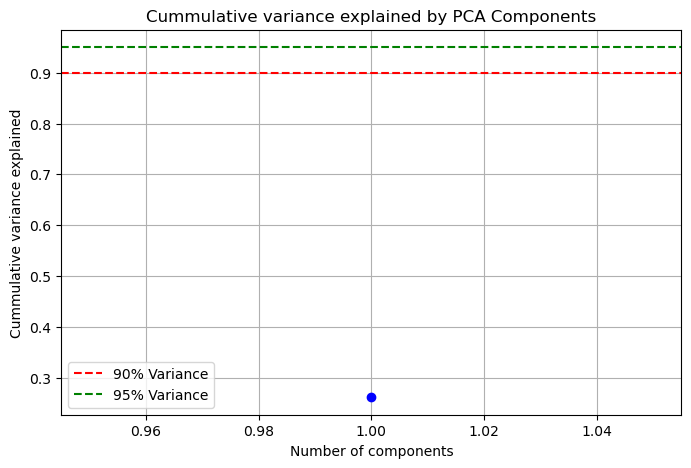

In [4]:
#Plot cummulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker = 'o', linestyle ='--', color ='b') 
plt.title("Cummulative variance explained by PCA Components")
plt.xlabel("Number of components")
plt.ylabel("Cummulative variance explained")
plt.axhline(y=0.9, color ='r', linestyle ='--', label = '90% Variance')
plt.axhline(y=0.95, color ='g', linestyle ='--', label = '95% Variance')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
#Print variance info
print("Explained Variance Ratio (each PC shows how much info it captures):")
print(explained_variance.round(3))

print("Cumulative Variance (how much total info is captured):")
print(cumulative_variance.round(3))

Explained Variance Ratio (each PC shows how much info it captures):
[0.262]
Cumulative Variance (how much total info is captured):
[0.262]


In [6]:
#9 .Find feature contribution(loadings)
#Loadings tell us how each original feature contributes each principal component
loadings = pd.DataFrame(
    pca.components_.T,    #transpose to get features as rows
    columns = [f'PC{i+1}' for i in range(pca.n_components_)],
    index = numeric_cols
)

print("Feature loadings (importance of each feature in each component):")
print(loadings.round(3))

Feature loadings (importance of each feature in each component):
                            PC1
Pregnancies               0.128
Glucose                   0.393
BloodPressure             0.360
SkinThickness             0.440
Insulin                   0.435
BMI                       0.452
DiabetesPedigreeFunction  0.271
Age                       0.198


In [7]:
#Add-on: Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [8]:
#10 . Select optimal number of components(e.g., for 95% variance)
#Find the index of the first component where cumulative variance is >= 0.95
index_of_95 = np.argmax(cumulative_variance >= 0.95)

In [9]:
#np.argmax returns the index of the first 'True'. If no True is found, it returns 0.
#We must check if the 95% target was actually reached at that index
if cumulative_variance[index_of_95] >= 0.95:
    n_opt = index_of_95 + 1
else:
    #if the target was Not reached, use all available components
    n_opt = len(explained_variance)

print("Optimal number of components to retain 95% variance",n_opt)

Optimal number of components to retain 95% variance 1


In [10]:
#use the optimally reduced data for modeling
X_pca_reduced = data_pca[:, :n_opt]

In [11]:
#11. Prepare Data and Model
y = df['Outcome']

In [56]:
#Split the data into training and testing sets
X_train, X_test, y_train,y_test = train_test_split(X_pca_reduced,y,test_size = 0.3, random_state = 42, stratify = y)

In [13]:
#Initialize and train the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear',random_state =42,max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [14]:
#12. Predict and Evaluate
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy : {accuracy:.4f}") 

Model Accuracy : 0.7316


In [15]:
#PCA on dummy student data, with covariance matrix
data = {
    "Maths":[95,88,92,70,68,75,45,50,40,60],
    "Science":[90,85,94,72,65,78,50,55,42,58],
    "English":[60,65,62,80,82,75,88,84,90,70],
    "Hindi":[58,63,60,78,85,72,90,82,88,68]
}

df = pd.DataFrame(data)
print(df)

   Maths  Science  English  Hindi
0     95       90       60     58
1     88       85       65     63
2     92       94       62     60
3     70       72       80     78
4     68       65       82     85
5     75       78       75     72
6     45       50       88     90
7     50       55       84     82
8     40       42       90     88
9     60       58       70     68


In [16]:
#Display covariance matrix
print("Covariance Matrix:")
cov_matrix = df.cov()
print(cov_matrix)

Covariance Matrix:
              Maths     Science     English       Hindi
Maths    384.233333  343.255556 -194.422222 -205.688889
Science  343.255556  314.988889 -170.600000 -182.177778
English -194.422222 -170.600000  118.266667  127.400000
Hindi   -205.688889 -182.177778  127.400000  140.488889


In [24]:
#Add a "Result" column
df['Result'] =((((df['Maths']) >= 60) | (df['Science'] >=60)) & (((df['English'] >= 60) | (df['Hindi'] >=60)))).astype(int)
print(df)
print(df.info())

   Maths  Science  English  Hindi  Result
0     95       90       60     58       1
1     88       85       65     63       1
2     92       94       62     60       1
3     70       72       80     78       1
4     68       65       82     85       1
5     75       78       75     72       1
6     45       50       88     90       0
7     50       55       84     82       0
8     40       42       90     88       0
9     60       58       70     68       1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Maths    10 non-null     int64
 1   Science  10 non-null     int64
 2   English  10 non-null     int64
 3   Hindi    10 non-null     int64
 4   Result   10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
None


In [18]:
#Save to CSV(optional)
df.to_csv("student_marks.csv", index= False)

In [25]:
#2. PCA + Logistic Regression
numeric_columns = ['Maths','Science','English','Hindi']

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[numeric_columns])

In [66]:
#3.Apply PCA
pca = PCA(n_components =2)
data_pca = pca.fit_transform(data_scaled)

In [67]:
#4 . Calculating variance and cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Explained Variance Ratio:", explained_variance.round(3))
print("Cumulative Variance:", cumulative_variance.round(3))
print(pca.n_components_)

Explained Variance Ratio: [0.94  0.054]
Cumulative Variance: [0.94  0.994]
2


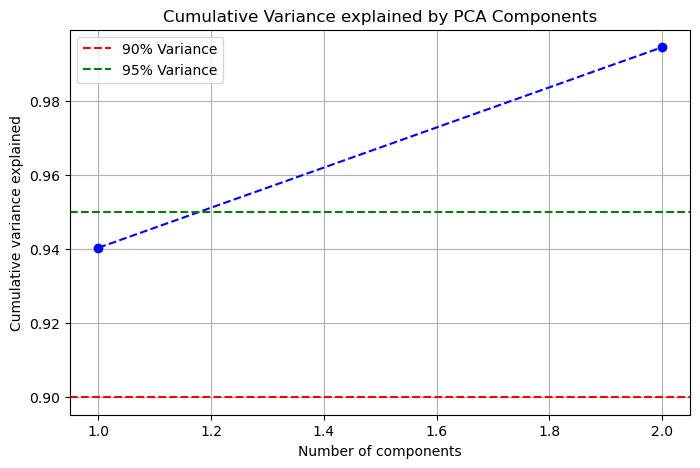

In [68]:
#5. Visualize
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker = 'o', linestyle ='--', color ='b') 
plt.title("Cumulative Variance explained by PCA Components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.axhline(y=0.9, color ='r', linestyle ='--', label = '90% Variance')
plt.axhline(y=0.95, color ='g', linestyle ='--', label = '95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [69]:
#6. Feature Loadings
contribute = pd.DataFrame(
    pca.components_.T, 
    columns = [f'PC{i+1}' for i in range(pca.n_components_)], 
    index = numeric_columns)
print(contribute.round(3))

           PC1    PC2
Maths   -0.503  0.440
Science -0.497  0.554
English  0.503  0.444
Hindi    0.497  0.550


In [70]:
index_of_95 = np.argmax(cumulative_variance >= 0.95)
if cumulative_variance[index_of_95] >= 0.95:
    n_opt = index_of_95 + 1
else:
    n_opt = len(explained_variance)

print("Optimal number of components to retain 95% variance",n_opt)
X_pca_reduced1 = data_pca[:, :n_opt]

Optimal number of components to retain 95% variance 2


In [71]:
#7. Logistic Regression on PCA-Reduced Data
y = df['Result']
X_train, X_test , y_train , y_test = train_test_split(X_pca_reduced1,y , test_size=0.3, random_state =42, stratify = y)

In [72]:
model = LogisticRegression(max_iter = 500)
model.fit(X_train,y_train)

LogisticRegression(max_iter=500)

In [73]:
y_pred1 = model.predict(X_test)
accuracy1 = accuracy_score(y_test,y_pred1)
print("Accuracy :", accuracy1*100)

Accuracy : 100.0


Center of Maths-Science:[68.3 68.9]
Covariance matrix:  [[384.23333333 343.25555556]
 [343.25555556 314.98888889]]
PC1 direction vector: [0.74173954 0.67068805]
PC1 eigenvalue (variance along PC1): 694.6083207974475


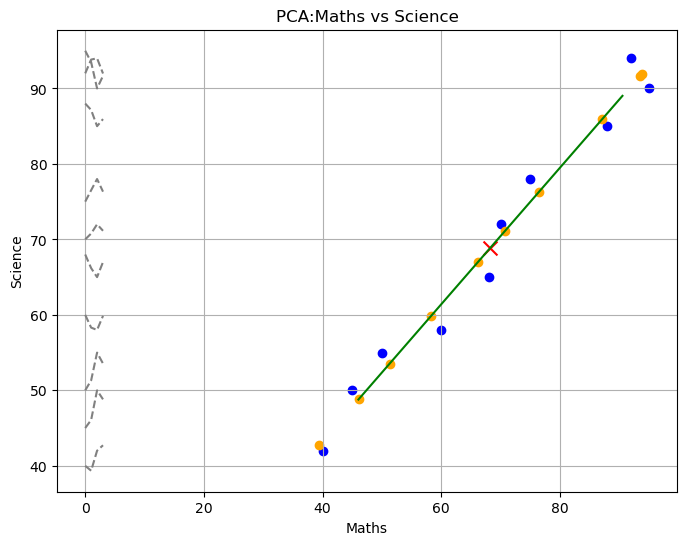

Center of Maths-English:[68.3 75.6]
Covariance matrix:  [[ 384.23333333 -194.42222222]
 [-194.42222222  118.26666667]]
PC1 direction vector: [ 0.88446631 -0.46660406]
PC1 eigenvalue (variance along PC1): 486.8016237224264


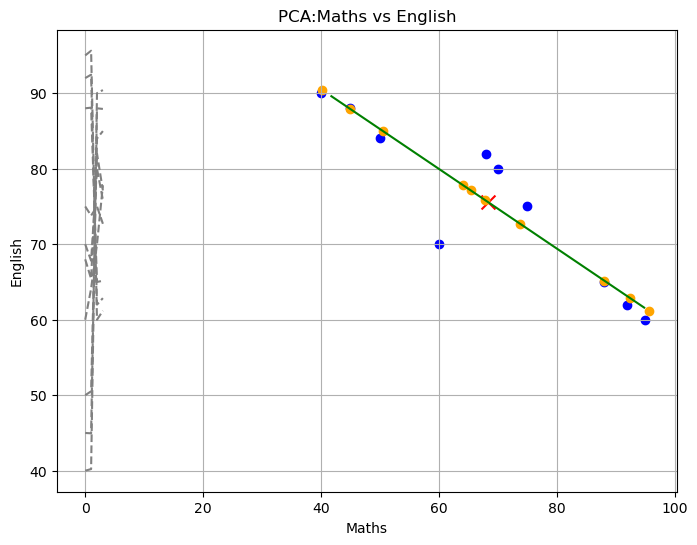

Summary of PC1 eigenvalues (varience along PC1):
Maths-Science PC1 eigenvalue: [0.74173954 0.67068805]
Maths-English PC1 eigenvalue: [ 0.88446631 -0.46660406]


In [82]:
#Visualizing PCA for better understanding
def pca_2d_plot_raw(X,xlabel,ylabel,title):
    #Compue center - This is center of the two columns
    #e.g. center of Maths-Science or MAths-English
    center = X.mean(axis=0)
    print(f"Center of {xlabel}-{ylabel}:{center}")

    #Center the data
    #Subtract center from each data point
    X_centered = X - center

    #Covariance matrix of the centered data
    cov_matrix = np.cov(X_centered.T)
    print("Covariance matrix: ",cov_matrix)

    #eigenvalues and eigenvectors
    #eig finds eigenvalues = amount of variance in each direction
    #how strongly data strectches in that direction
    #eigenvectors = directions themselves
    #For 2d data, we get 2 eigenvalues, called lambda1 and lambda2
    eig_values,eig_vecs = np.linalg.eig(cov_matrix)

    #which eigenvalues is higher? Shows maximum variance
    #Gives us PC1
    idx_max = np.argmax(eig_values)

    #PC1 = Line where data shows maximum spread
    pc1 = eig_vecs[:,idx_max]

    #Actual amount of variance along PC1
    #High value: Data is stretched along the line, small = not much
    pc1_val = eig_values[idx_max]
    print("PC1 direction vector:",pc1)
    print("PC1 eigenvalue (variance along PC1):", pc1_val)

    #Project points onto PC1
    projections = X_centered.dot(pc1).reshape(-1,1)*pc1
    projected_points = center + projections

    #plot
    plt.figure(figsize =(8,6))
    plt.scatter(X[:,0], X[:,1],color ='blue')
    plt.scatter(center[0],center[1],color ='red',marker ='x', s=100)
    plt.scatter(projected_points[:,0],projected_points[:,1],color = 'orange')

    line_length = 30
    pc1_line = np.array([center -pc1*line_length,center + pc1 * line_length])
    plt.plot(pc1_line[:,0],pc1_line[:,1],color ='green')

    for original, projected in zip(X,projected_points):
        plt.plot([original[0],projected[0],original[1],projected[1]],color = 'gray', linestyle = '--')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

    return pc1

#Maths vs Science(less spread)
X1 = np.array([data['Maths'],data['Science']]).T
pc1_val1 = pca_2d_plot_raw(X1, "Maths",'Science',"PCA:Maths vs Science")    

#Maths vs English(morespread)
X2 = np.array([data['Maths'],data['English']]).T
pc1_val2 = pca_2d_plot_raw(X2, "Maths",'English',"PCA:Maths vs English")

print("Summary of PC1 eigenvalues (varience along PC1):")
print("Maths-Science PC1 eigenvalue:",pc1_val1)
print("Maths-English PC1 eigenvalue:",pc1_val2)